Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("Loading and Preprocessing WSER Data...\n")

# 1. Load the compiled dataset from Notebook 1
df = pd.read_csv("WSER_Master_ML_Dataset.csv")

# 2. Categorical Encoding
# Machine learning algorithms require numbers, so we map Gender to a binary integer
df['Is_Male'] = df['Runner_Gender'].map({'M': 1, 'F': 0})

Loading and Preprocessing WSER Data...



In [3]:
# 3. Define Features and Target
feature_columns = [
    'Runner_Age', 
    'Is_Male', 
    'Pace_Start_to_Robinson', 
    'Pace_Canyons', 
    'Pace_Degradation_Canyons', 
    'High_F', 
    'June_10_Snow'
]

X = df[feature_columns]
y = df['Status']

In [4]:
# 4. Train/Test Split
# stratify=y ensures we maintain the exact ratio of Finishers to DNFs in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# 5. Imputation (filling any missing age/gender data mathematically)
imputer = IterativeImputer(random_state=42)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 6. Standardization
# Scales all features to have a mean of 0 and standard deviation of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convert back to dataframes for easy reference later
X_train_final = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=feature_columns)

print("Data Preprocessing Complete! Training data shape:", X_train_final.shape)

Data Preprocessing Complete! Training data shape: (2367, 7)


Model training and metrics

In [6]:
print("Training Machine Learning Models...\n")

# ---------------------------------------------------------
# MODEL 1: Logistic Regression (The Baseline)
# ---------------------------------------------------------
log_reg_model = LogisticRegression(class_weight='balanced', random_state=42)
log_reg_model.fit(X_train_final, y_train)
log_reg_preds = log_reg_model.predict(X_test_final)

# ---------------------------------------------------------
# MODEL 2: Random Forest Classifier (The Complex Ensemble)
# max_depth=5 prevents the trees from overfitting the training data
# ---------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=5, random_state=42)
rf_model.fit(X_train_final, y_train)
rf_preds = rf_model.predict(X_test_final)

print("--- LOGISTIC REGRESSION RESULTS (Mile 62) ---")
print(classification_report(y_test, log_reg_preds, target_names=['DNF (0)', 'Finish (1)']))

print("\n--- RANDOM FOREST RESULTS (Mile 62) ---")
print(classification_report(y_test, rf_preds, target_names=['DNF (0)', 'Finish (1)']))

Training Machine Learning Models...

--- LOGISTIC REGRESSION RESULTS (Mile 62) ---
              precision    recall  f1-score   support

     DNF (0)       0.25      0.72      0.37        80
  Finish (1)       0.94      0.66      0.78       512

    accuracy                           0.67       592
   macro avg       0.59      0.69      0.57       592
weighted avg       0.85      0.67      0.72       592


--- RANDOM FOREST RESULTS (Mile 62) ---
              precision    recall  f1-score   support

     DNF (0)       0.37      0.57      0.45        80
  Finish (1)       0.93      0.85      0.88       512

    accuracy                           0.81       592
   macro avg       0.65      0.71      0.67       592
weighted avg       0.85      0.81      0.83       592



Initiating Threshold Tuning for Random Forest...

Default 50% Threshold DNF F1-Score: 0.507
Optimal Threshold: 0.63 (or 63%)
New Tuned DNF F1-Score: 0.491


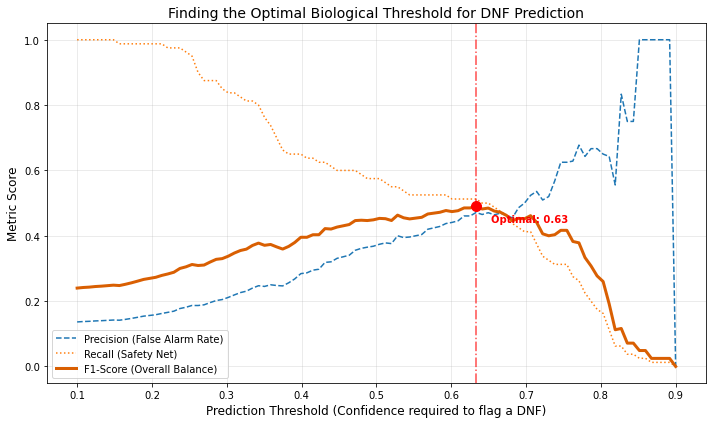

In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("Initiating Threshold Tuning for Random Forest...\n")

# 1. Get the raw probability of DNF (Class 0)
# predict_proba returns a 2D array: [Probability of Class 0, Probability of Class 1]
# We want the first column ([:, 0]), which is the probability the runner will DNF.
rf_probs_dnf = rf_model.predict_proba(X_test_final)[:, 0]

# 2. Test 100 different thresholds between 10% and 90%
thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = []
precisions = []
recalls = []

for thresh in thresholds:
    # If the probability of DNF is greater than our threshold, predict 0 (DNF). Otherwise, 1 (Finish).
    custom_preds = np.where(rf_probs_dnf >= thresh, 0, 1)
    
    # Calculate metrics specifically for the DNF class (pos_label=0)
    f1_scores.append(f1_score(y_test, custom_preds, pos_label=0))
    precisions.append(precision_score(y_test, custom_preds, pos_label=0, zero_division=0))
    recalls.append(recall_score(y_test, custom_preds, pos_label=0))

# 3. Find the optimal threshold
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
best_f1 = f1_scores[optimal_idx]

print(f"Default 50% Threshold DNF F1-Score: {f1_score(y_test, rf_preds, pos_label=0):.3f}")
print(f"Optimal Threshold: {optimal_threshold:.2f} (or {optimal_threshold*100:.0f}%)")
print(f"New Tuned DNF F1-Score: {best_f1:.3f}")

# ==========================================
# Figure 5: The Threshold Trade-off Curve
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision (False Alarm Rate)', linestyle='--')
plt.plot(thresholds, recalls, label='Recall (Safety Net)', linestyle=':')
plt.plot(thresholds, f1_scores, label='F1-Score (Overall Balance)', linewidth=3, color='#d95f02')

# Mark the optimal point
plt.axvline(x=optimal_threshold, color='red', linestyle='-.', alpha=0.7)
plt.scatter(optimal_threshold, best_f1, color='red', s=100, zorder=5)
plt.text(optimal_threshold + 0.02, best_f1 - 0.05, f'Optimal: {optimal_threshold:.2f}', color='red', fontweight='bold')

plt.title('Finding the Optimal Biological Threshold for DNF Prediction', fontsize=14)
plt.xlabel('Prediction Threshold (Confidence required to flag a DNF)', fontsize=12)
plt.ylabel('Metric Score', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Confusion Matirx

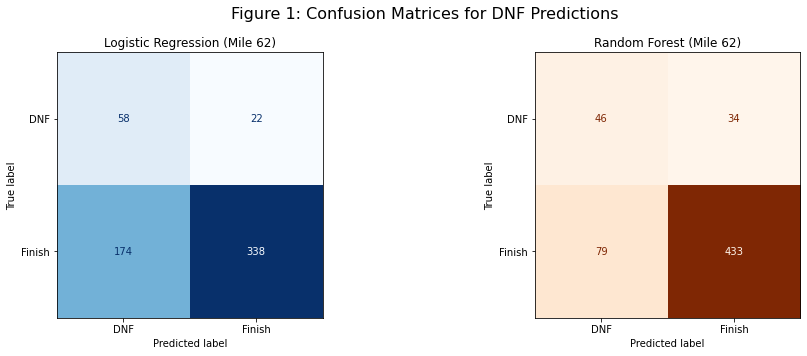

In [7]:
# ---------------------------------------------------------
# Figure 1: Confusion Matrices
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

# Plot Logistic Regression Matrix
cm_log = confusion_matrix(y_test, log_reg_preds)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['DNF', 'Finish'])
disp_log.plot(ax=axes1[0], cmap='Blues', colorbar=False)
axes1[0].set_title('Logistic Regression (Mile 62)')
axes1[0].grid(False)

# Plot Random Forest Matrix
cm_rf = confusion_matrix(y_test, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['DNF', 'Finish'])
disp_rf.plot(ax=axes1[1], cmap='Oranges', colorbar=False)
axes1[1].set_title('Random Forest (Mile 62)')
axes1[1].grid(False)

plt.suptitle('Figure 1: Confusion Matrices for DNF Predictions', fontsize=16)
plt.tight_layout()
plt.show()

Feature Importance

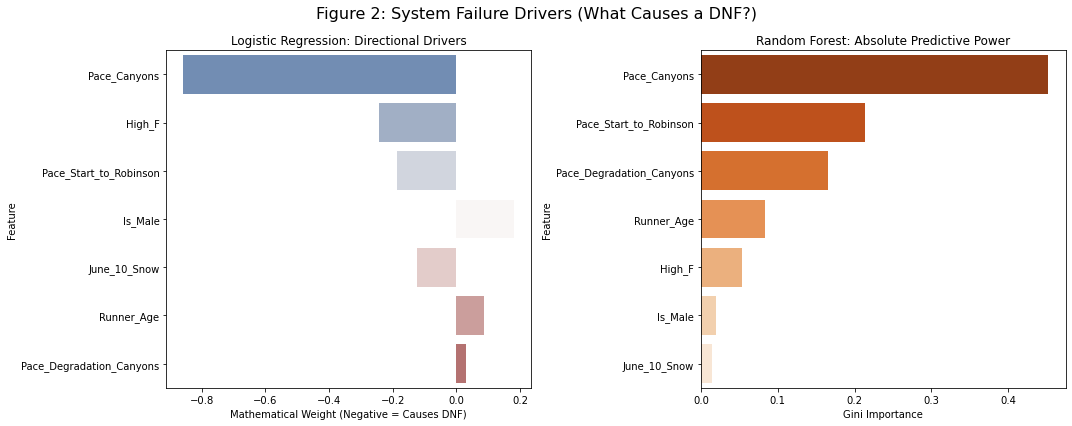


Visualizations rendered for inspection.


In [8]:
# ---------------------------------------------------------
# Figure 2: Feature Importances
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))

# Extract Logistic Regression Coefficients (Directional)
log_importances = pd.DataFrame({'Feature': feature_columns, 'Coefficient': log_reg_model.coef_[0]})
log_importances['Abs_Coef'] = log_importances['Coefficient'].abs()
log_importances = log_importances.sort_values(by='Abs_Coef', ascending=False)

sns.barplot(x='Coefficient', y='Feature', data=log_importances, ax=axes2[0], palette="vlag")
axes2[0].set_title('Logistic Regression: Directional Drivers')
axes2[0].set_xlabel('Mathematical Weight (Negative = Causes DNF)')

# Extract Random Forest Importances (Absolute Power)
rf_importances = pd.DataFrame({'Feature': feature_columns, 'Importance': rf_model.feature_importances_})
rf_importances = rf_importances.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=rf_importances, ax=axes2[1], palette="Oranges_r")
axes2[1].set_title('Random Forest: Absolute Predictive Power')
axes2[1].set_xlabel('Gini Importance')

plt.suptitle('Figure 2: System Failure Drivers (What Causes a DNF?)', fontsize=16)
plt.tight_layout()
plt.show()

print("\nVisualizations rendered for inspection.")

In [9]:
from sklearn.metrics import f1_score
from sklearn.svm import SVC

print("Simulating Predictions Across Aid Stations...\n")

# Define the data available to the model at each physical location
checkpoints = {
    'Robinson Flat (Mile 30)': {
        'filter_col': 'Pace_Start_to_Robinson',
        'features': ['Runner_Age', 'Is_Male', 'High_F', 'June_10_Snow', 'Pace_Start_to_Robinson'],
        'miles_left': 69.7
    },
    'Michigan Bluff (Mile 55)': {
        'filter_col': 'Pace_Canyons',
        'features': ['Runner_Age', 'Is_Male', 'High_F', 'June_10_Snow', 
                     'Pace_Start_to_Robinson', 'Pace_Canyons', 'Pace_Degradation_Canyons'],
        'miles_left': 44.3
    },
    'Foresthill (Mile 62)': {
        'filter_col': 'Pace_MB_to_FH',
        'features': ['Runner_Age', 'Is_Male', 'High_F', 'June_10_Snow', 
                     'Pace_Start_to_Robinson', 'Pace_Canyons', 'Pace_Degradation_Canyons', 
                     'Pace_MB_to_FH', 'Pace_Degradation_FH'],
        'miles_left': 38.0
    }
}

# Dictionaries to store the results
rf_f1_scores = []
svc_f1_scores = []
actionable_miles = []
labels = []

# Loop through space and time
for name, data in checkpoints.items():
    print(f"Training models at {name}...")
    
    # 1. Survivorship Bias Filter (Only look at runners who made it to this specific point)
    df_checkpoint = df.dropna(subset=[data['filter_col']]).copy()
    
    X_cp = df_checkpoint[data['features']]
    y_cp = df_checkpoint['Status']
    
    # 2. Preprocess
    X_train_cp, X_test_cp, y_train_cp, y_test_cp = train_test_split(X_cp, y_cp, test_size=0.2, random_state=42, stratify=y_cp)
    
    X_train_imp = imputer.fit_transform(X_train_cp)
    X_test_imp = imputer.transform(X_test_cp)
    
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_sc = scaler.transform(X_test_imp)
    
    # 3. Train Models
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=5, random_state=42)
    rf.fit(X_train_sc, y_train_cp)
    rf_preds = rf.predict(X_test_sc)
    
    # Adding an SVC just to prove the pattern holds across different mathematics
    svc = SVC(class_weight='balanced', kernel='rbf', random_state=42)
    svc.fit(X_train_sc, y_train_cp)
    svc_preds = svc.predict(X_test_sc)
    
    # 4. Extract and Save the DNF (Class 0) F1-Score
    # target_names[0] is DNF, we want the macro F1 or just the Class 0 F1.
    # We will grab the strict DNF detection score.
    report_rf = classification_report(y_test_cp, rf_preds, output_dict=True)
    report_svc = classification_report(y_test_cp, svc_preds, output_dict=True)
    
    # Assuming '0' or '0.0' is the DNF class key in the dictionary
    dnf_key = [k for k in report_rf.keys() if k in ['0', '0.0', 'False']][0]
    
    rf_f1_scores.append(report_rf[dnf_key]['f1-score'])
    svc_f1_scores.append(report_svc[dnf_key]['f1-score'])
    actionable_miles.append(data['miles_left'])
    labels.append(name)

print("\nTemporal simulation complete!")

Simulating Predictions Across Aid Stations...

Training models at Robinson Flat (Mile 30)...
Training models at Michigan Bluff (Mile 55)...
Training models at Foresthill (Mile 62)...

Temporal simulation complete!


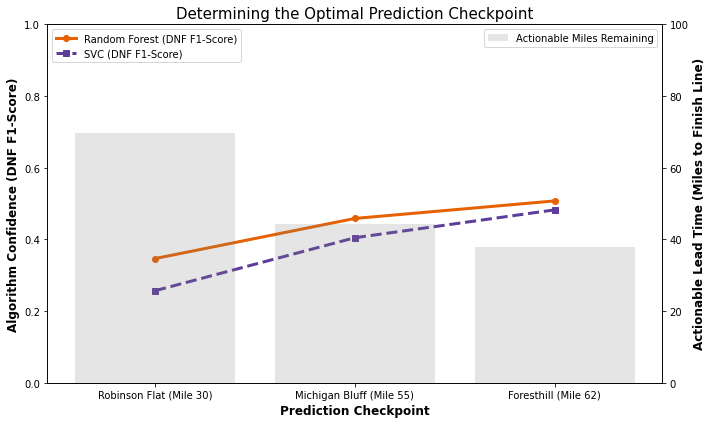

In [10]:
# ==========================================
# Figure 4: The Actionability Trade-off Curve
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Y-Axis: Model Accuracy
ax1.plot(labels, rf_f1_scores, marker='o', linewidth=3, color='#e66101', label='Random Forest (DNF F1-Score)')
ax1.plot(labels, svc_f1_scores, marker='s', linewidth=3, color='#5e3c99', linestyle='--', label='SVC (DNF F1-Score)')
ax1.set_xlabel('Prediction Checkpoint', fontsize=12, fontweight='bold')
ax1.set_ylabel('Algorithm Confidence (DNF F1-Score)', fontsize=12, fontweight='bold')
ax1.set_ylim(0.0, 1.0)
ax1.legend(loc='upper left')

# Secondary Y-Axis: Actionable Lead Time (Miles remaining to fix the problem)
ax2 = ax1.twinx()
ax2.bar(labels, actionable_miles, alpha=0.2, color='gray', label='Actionable Miles Remaining')
ax2.set_ylabel('Actionable Lead Time (Miles to Finish Line)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper right')

plt.title('Determining the Optimal Prediction Checkpoint', fontsize=15)
plt.tight_layout()
plt.show()